In [ ]:
!pip install scikit-posthocs
!pip install statsmodels


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro, mannwhitneyu, ttest_ind
from scipy.stats import kruskal
import scikit_posthocs as sp

# Organised datasets

### Preprocessig Pipeline
<!-- ``` -->
Pipeline steps:
* number of sheets

* sheet currently processing

* float columns detected

* labels assigned

* imputation status

* normaliser detected

* ΔCt done or skipped

* processing summary
<!-- ``` -->

In [ ]:
import pandas as pd

INPUT_FILE = "data/Copy new draft 6.xlsx"
OUTPUT_FILE = "data/intrmd/preprocessed_data.xlsx"

# Predefined normalisers
normaliser_list = [
    'let-7c_ct_mean',
    'actin_ct_mean',
    'srm_u6_ct_mean',
    'tis_u6_ct_mean'
]

# Read all sheets
sheets_dict = pd.read_excel(INPUT_FILE, sheet_name=None)
processed_sheets = {}

print(f"Total sheets found: {len(sheets_dict)}\n")

for sheet_name, df in sheets_dict.items():
    print(f"==============================")
    print(f" Processing Sheet: {sheet_name}")
    print(f"==============================")

    raw_df = df.copy()

    # ---- Basic datatype settings ----
    df['groups'] = df['groups'].astype('string')
    df["groups"] = df["groups"].str.upper().str.strip() # groups in capital
    # Create labels
    df['labels'] = df['groups'].str.upper().map({'BPH': 0, 'PCA': 1})
    print("Labels assigned successfully.")

    # ---- Numeric float columns ----
    float_cols = df.select_dtypes(include='float').columns
    print(f"Float columns detected ({len(float_cols)}): {list(float_cols)}")

    # ---- Group-wise median imputation ----
    df[float_cols] = (
        df
        .groupby('groups')[float_cols]
        .transform(lambda x: x.fillna(x.median()))
    )
    print("Group-wise median imputation done.")

    # ---- Detect normaliser ----
    available_normalisers = [n for n in normaliser_list if n in df.columns]

    if len(available_normalisers) == 0:
        print("❌ No normaliser found. Skipping ΔCt for this sheet.")
    else:
        normaliser = available_normalisers[0]
        print(f"✔ Normaliser detected: {normaliser}")

        # Pick biomarker ct mean columns
        ct_mean_cols = [c for c in df.columns
                        if c.endswith('_ct_mean') and c != normaliser]

        print(f"Biomarker mean columns: {ct_mean_cols}")

        # ΔCt calculation
        for col in ct_mean_cols:
            delta_col = col.replace('_ct_mean', '_delta_ct')
            df[delta_col] = df[col] - df[normaliser]

        print("ΔCt calculation completed.")

    print(f"Sheet '{sheet_name}' preprocessing completed.\n")

    processed_sheets[sheet_name] = df


# ---- Save all sheets to a single Excel ----
with pd.ExcelWriter(OUTPUT_FILE) as writer:
    for name, df in processed_sheets.items():
        df.to_excel(writer, sheet_name=name, index=False)

print("\n=====================================")
print(f" All sheets successfully processed.")
print(f" Saved to: {OUTPUT_FILE}")
print("=====================================")

Total sheets found: 4

 Processing Sheet: urine
Labels assigned successfully.
Float columns detected (7): ['urn_21-5p_ct_mean', 'urn_21-5p_delta_ct', 'urn_19b-3p_ct_mean', 'urn_19b-3p_delta_ct', 'urn_mir-375_ct_mean', 'urn_mir-375_delta_ct', 'let-7c_ct_mean']
Group-wise median imputation done.
✔ Normaliser detected: let-7c_ct_mean
Biomarker mean columns: ['urn_21-5p_ct_mean', 'urn_19b-3p_ct_mean', 'urn_mir-375_ct_mean']
ΔCt calculation completed.
Sheet 'urine' preprocessing completed.

 Processing Sheet: blood
Labels assigned successfully.
Float columns detected (7): ['bld_21-5p_ct_mean', 'bld_21-5p_delta_ct', 'bld_19b-3p_ct_mean', 'bld_19b-3p_delta_ct', 'bld_mir-375_ct_mean', 'bld_mir-375_delta_ct', 'actin_ct_mean']
Group-wise median imputation done.
✔ Normaliser detected: actin_ct_mean
Biomarker mean columns: ['bld_21-5p_ct_mean', 'bld_19b-3p_ct_mean', 'bld_mir-375_ct_mean']
ΔCt calculation completed.
Sheet 'blood' preprocessing completed.

 Processing Sheet: serum
Labels assigned su

# Statistical analysis

## A. Within biofluids analysis


BIOFLUID: URINE

Group counts:
labels
1    28
0    16
Name: count, dtype: int64

Delta Ct biomarkers:
['urn_21-5p_delta_ct', 'urn_19b-3p_delta_ct', 'urn_mir-375_delta_ct']

Biomarker: urn_21-5p_delta_ct
BPH stats:
  mean: 4.2783
  median: 4.3647
  std: 1.9545
  iqr: 2.4764
PCA stats:
  mean: 4.9349
  median: 5.0940
  std: 3.4323
  iqr: 4.9015
Normality p-values -> BPH: 0.4582, PCA: 0.5663
Statistical test: Independent t-test
p-value: 0.4233
AUC (direction-corrected): 0.5558
Direction: PCA > BPH


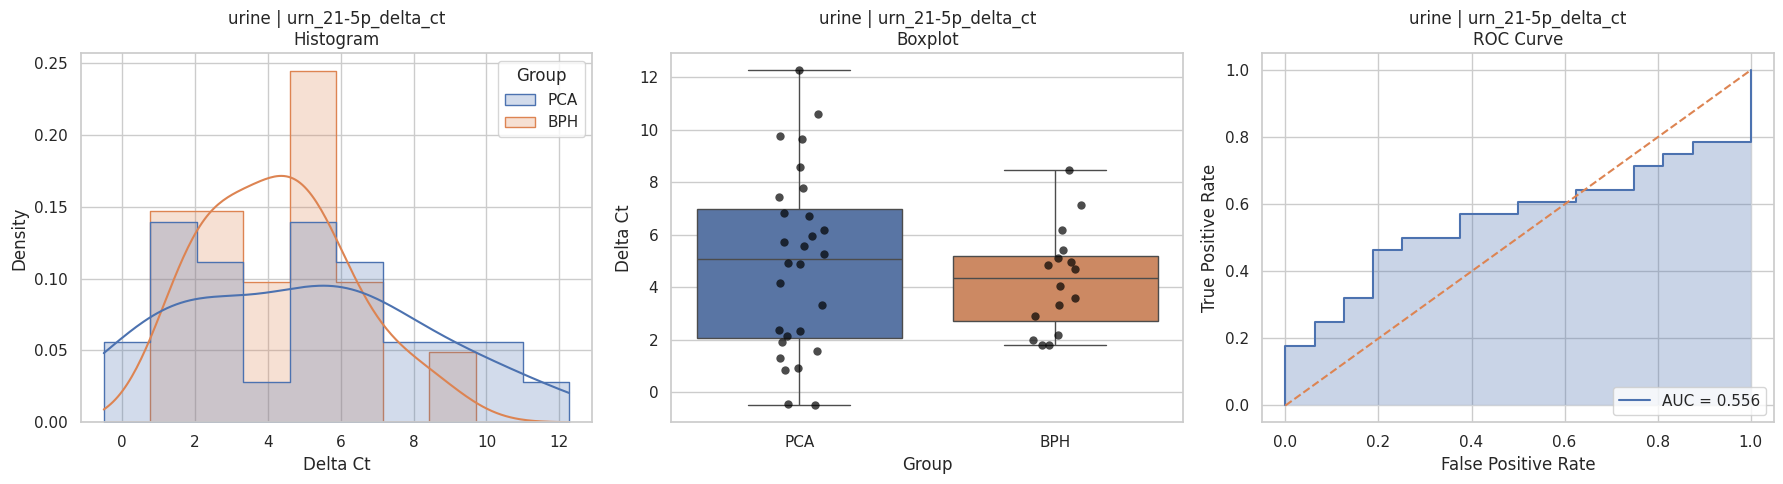


Biomarker: urn_19b-3p_delta_ct
BPH stats:
  mean: 3.2439
  median: 2.7692
  std: 2.3409
  iqr: 3.2122
PCA stats:
  mean: 4.1024
  median: 4.3976
  std: 3.5299
  iqr: 5.0322
Normality p-values -> BPH: 0.3995, PCA: 0.7064
Statistical test: Independent t-test
p-value: 0.3390
AUC (direction-corrected): 0.5737
Direction: PCA > BPH


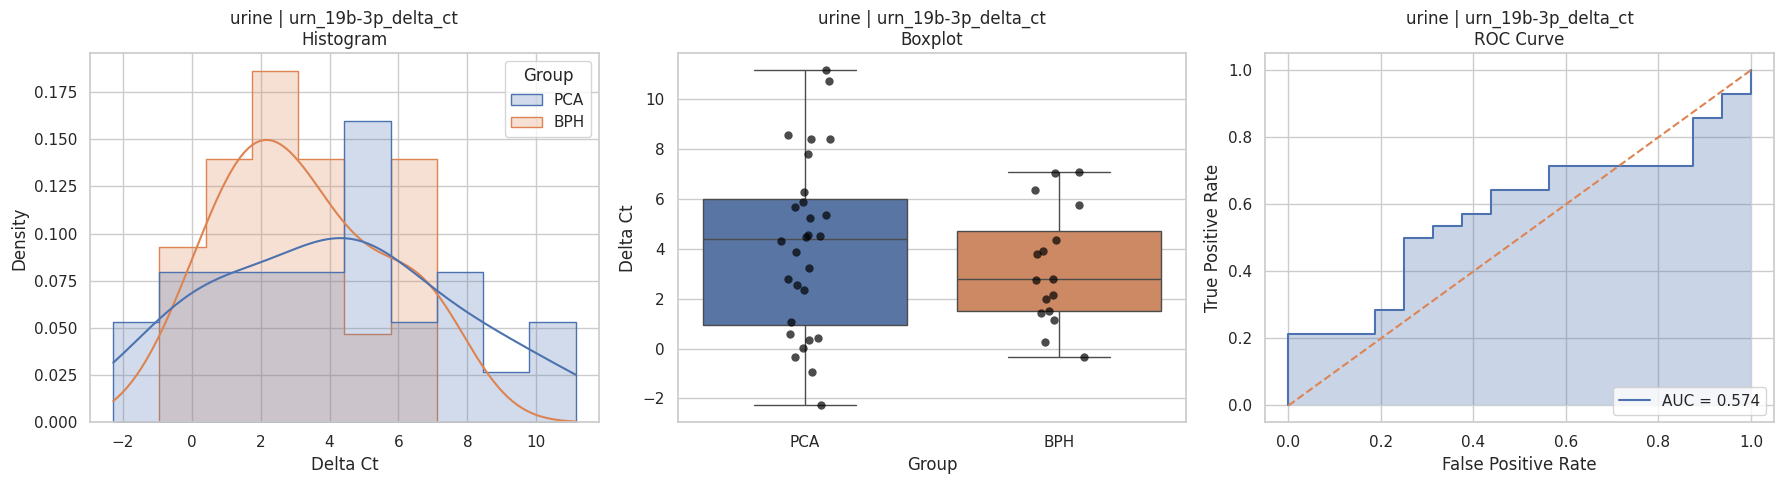


Biomarker: urn_mir-375_delta_ct
BPH stats:
  mean: 8.3240
  median: 8.5972
  std: 1.7789
  iqr: 1.2181
PCA stats:
  mean: 7.5445
  median: 6.9155
  std: 3.4052
  iqr: 3.9185
Normality p-values -> BPH: 0.1226, PCA: 0.8193
Statistical test: Independent t-test
p-value: 0.3247
AUC (direction-corrected): 0.5915
Direction: PCA < BPH (ΔCt inverted)


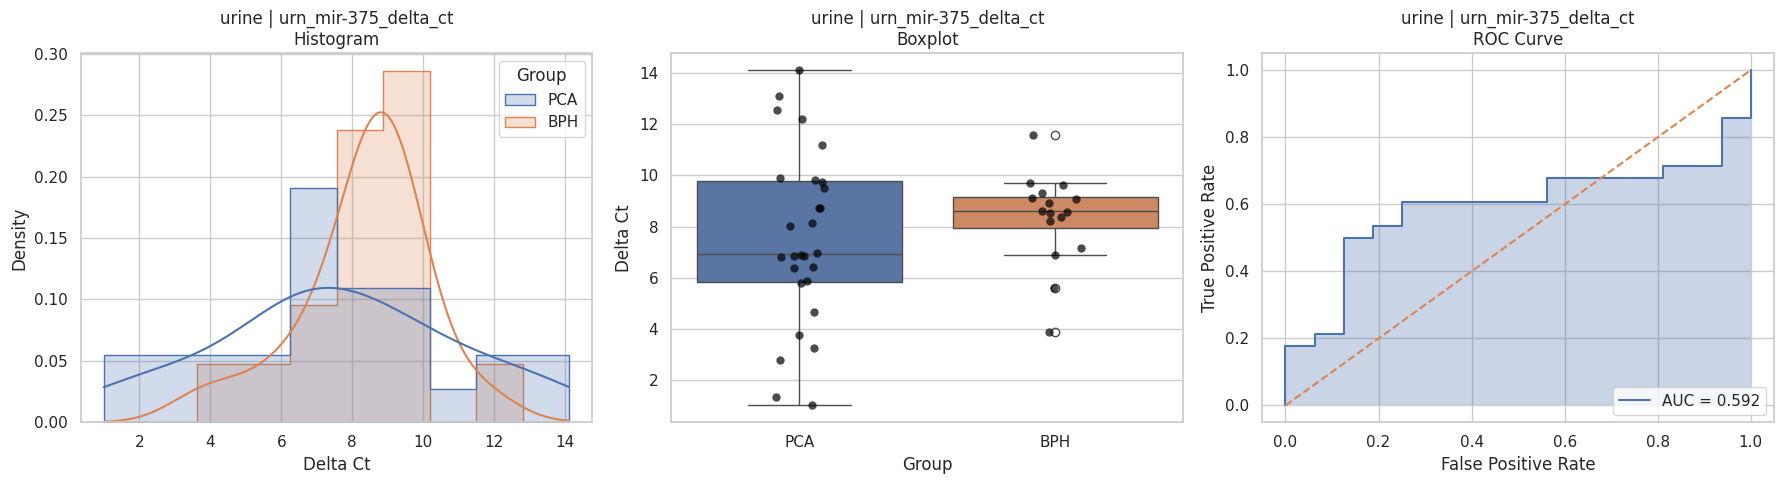


BIOFLUID: BLOOD

Group counts:
labels
1    35
0    26
Name: count, dtype: int64

Delta Ct biomarkers:
['bld_21-5p_delta_ct', 'bld_19b-3p_delta_ct', 'bld_mir-375_delta_ct']

Biomarker: bld_21-5p_delta_ct
BPH stats:
  mean: -1.1607
  median: -1.2120
  std: 1.9440
  iqr: 2.8257
PCA stats:
  mean: -0.3714
  median: -0.3580
  std: 2.8491
  iqr: 2.4040
Normality p-values -> BPH: 0.6358, PCA: 0.0001
Statistical test: Mann–Whitney U
p-value: 0.3178
AUC (direction-corrected): 0.5758
Direction: PCA > BPH


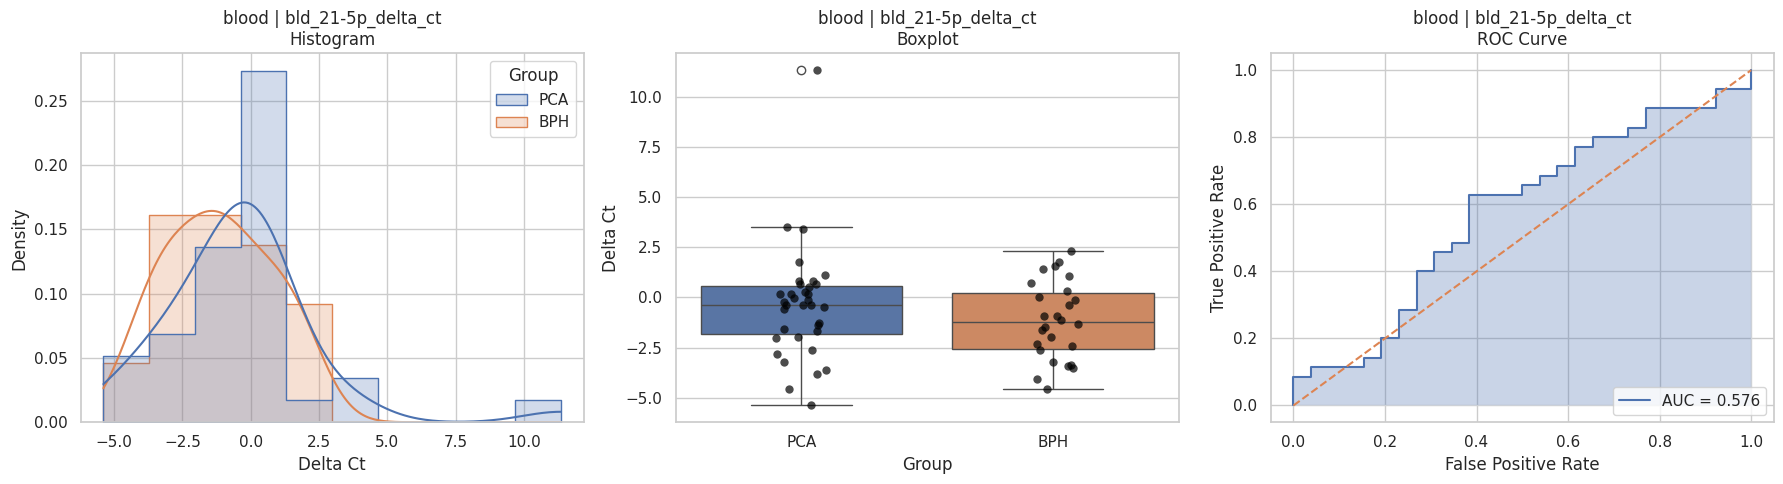


Biomarker: bld_19b-3p_delta_ct
BPH stats:
  mean: -4.4982
  median: -5.6288
  std: 3.4651
  iqr: 3.2570
PCA stats:
  mean: -2.6636
  median: -3.3940
  std: 4.4874
  iqr: 3.5751
Normality p-values -> BPH: 0.0003, PCA: 0.0000
Statistical test: Mann–Whitney U
p-value: 0.0282
AUC (direction-corrected): 0.6659
Direction: PCA > BPH


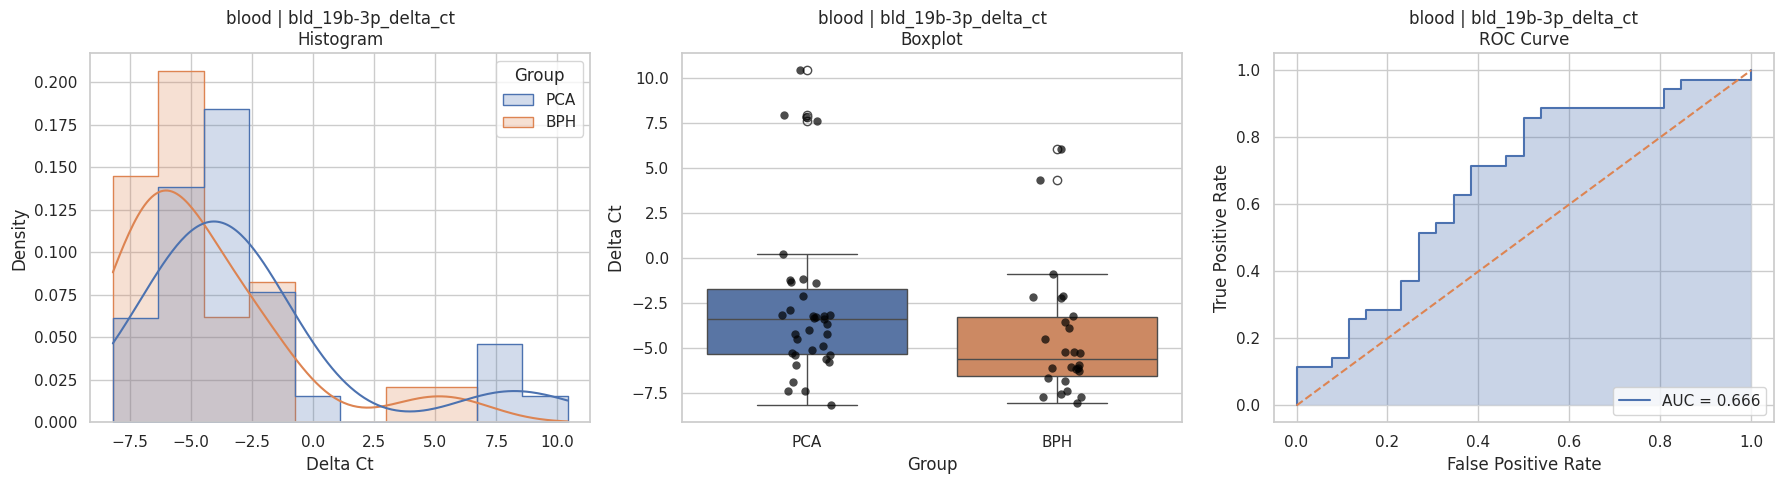


Biomarker: bld_mir-375_delta_ct
BPH stats:
  mean: 7.3682
  median: 7.3657
  std: 2.3424
  iqr: 2.6929
PCA stats:
  mean: 7.9288
  median: 7.8520
  std: 2.3414
  iqr: 2.9195
Normality p-values -> BPH: 0.0237, PCA: 0.1794
Statistical test: Mann–Whitney U
p-value: 0.3108
AUC (direction-corrected): 0.5769
Direction: PCA > BPH


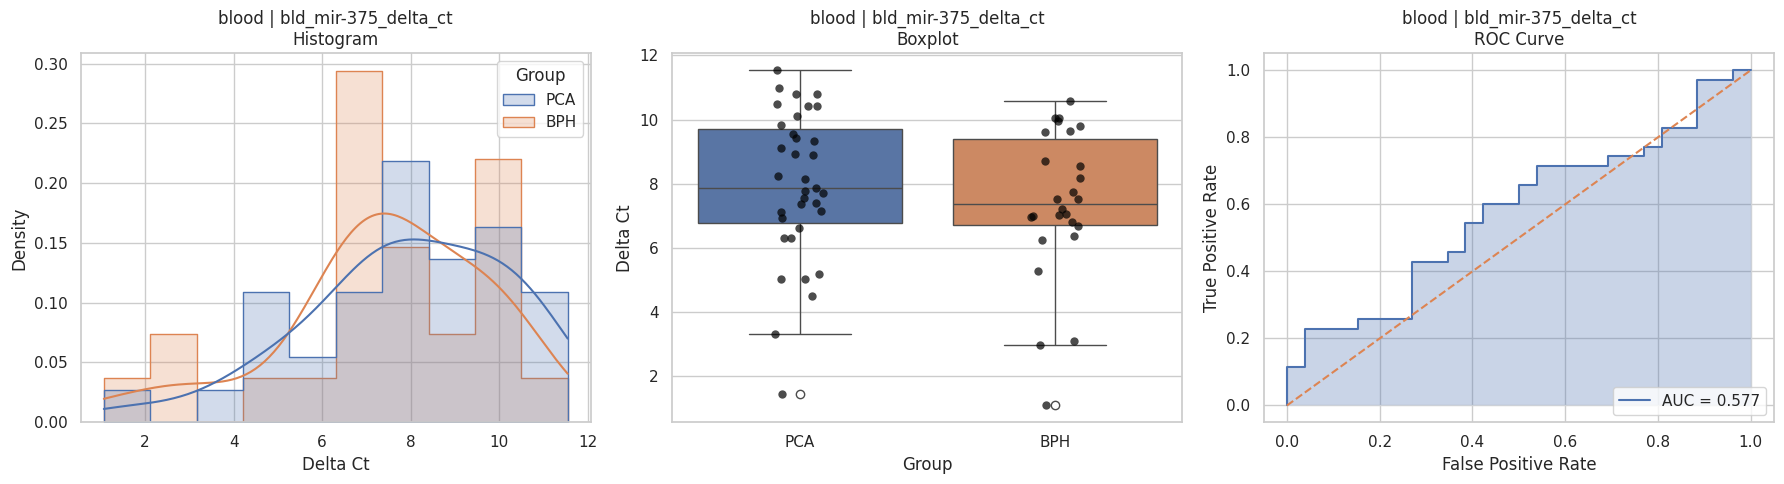


BIOFLUID: SERUM

Group counts:
labels
0    21
1    21
Name: count, dtype: int64

Delta Ct biomarkers:
['srm_21-5p_delta_ct', 'srm_19b-3p_delta_ct', 'srm_mir-375_delta_ct']

Biomarker: srm_21-5p_delta_ct
BPH stats:
  mean: 0.7398
  median: 0.7279
  std: 3.5942
  iqr: 6.3072
PCA stats:
  mean: 0.2728
  median: 1.0423
  std: 3.4463
  iqr: 3.9930
Normality p-values -> BPH: 0.0156, PCA: 0.3526
Statistical test: Mann–Whitney U
p-value: 0.9198
AUC (direction-corrected): 0.5102
Direction: PCA < BPH (ΔCt inverted)


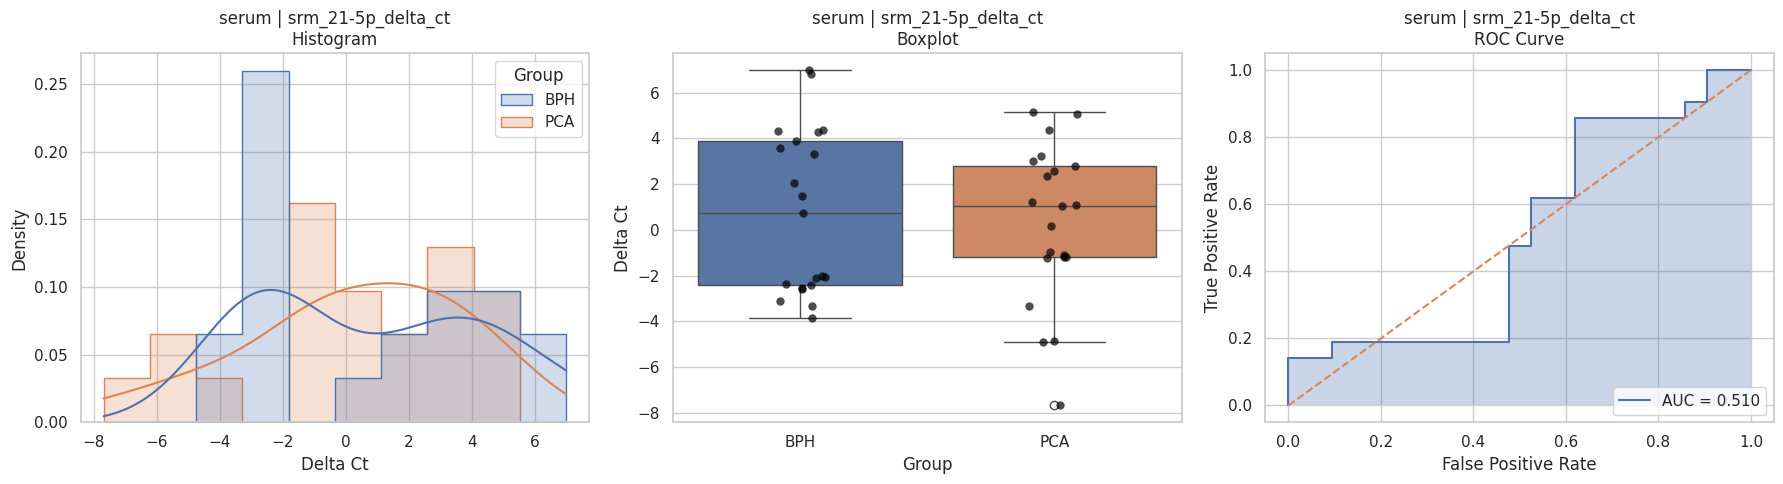


Biomarker: srm_19b-3p_delta_ct
BPH stats:
  mean: -7.5999
  median: -7.1822
  std: 2.8598
  iqr: 3.8400
PCA stats:
  mean: -8.4731
  median: -7.0650
  std: 2.8066
  iqr: 4.8501
Normality p-values -> BPH: 0.6943, PCA: 0.0294
Statistical test: Mann–Whitney U
p-value: 0.4065
AUC (direction-corrected): 0.5760
Direction: PCA < BPH (ΔCt inverted)


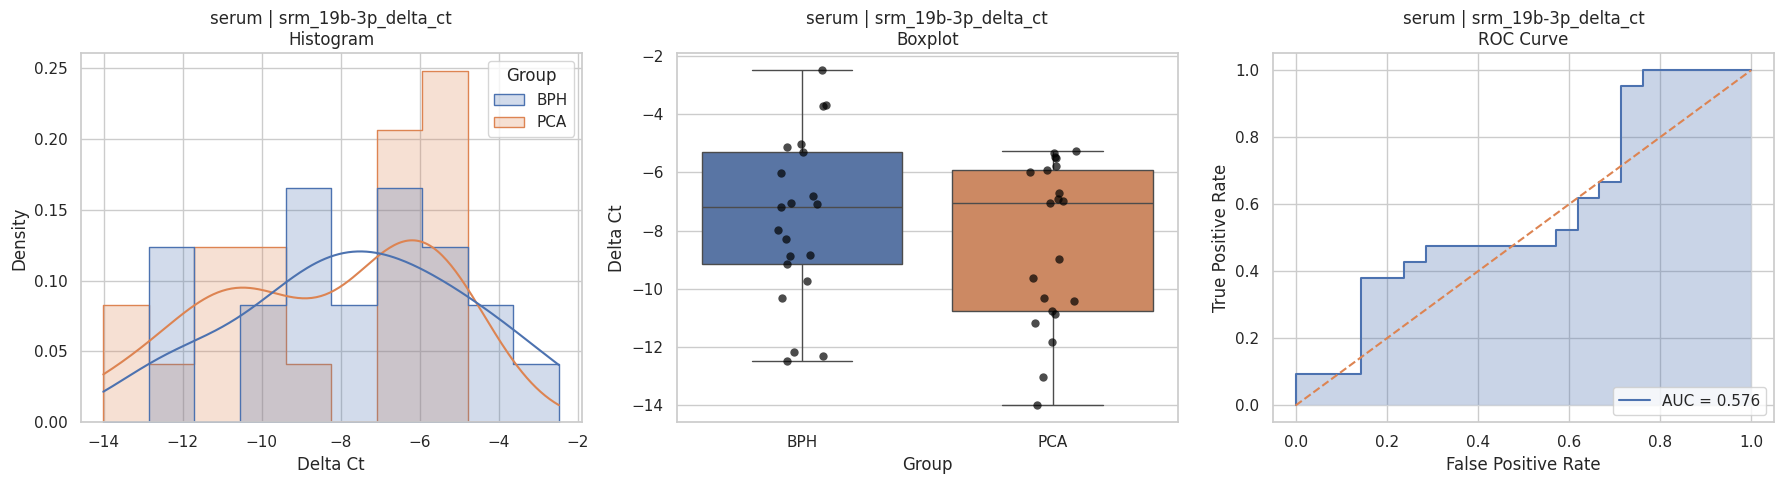


Biomarker: srm_mir-375_delta_ct
BPH stats:
  mean: -2.3480
  median: -2.1541
  std: 3.3831
  iqr: 3.7238
PCA stats:
  mean: -3.5124
  median: -3.3630
  std: 2.6238
  iqr: 3.8302
Normality p-values -> BPH: 0.8935, PCA: 0.0882
Statistical test: Independent t-test
p-value: 0.2203
AUC (direction-corrected): 0.5873
Direction: PCA < BPH (ΔCt inverted)


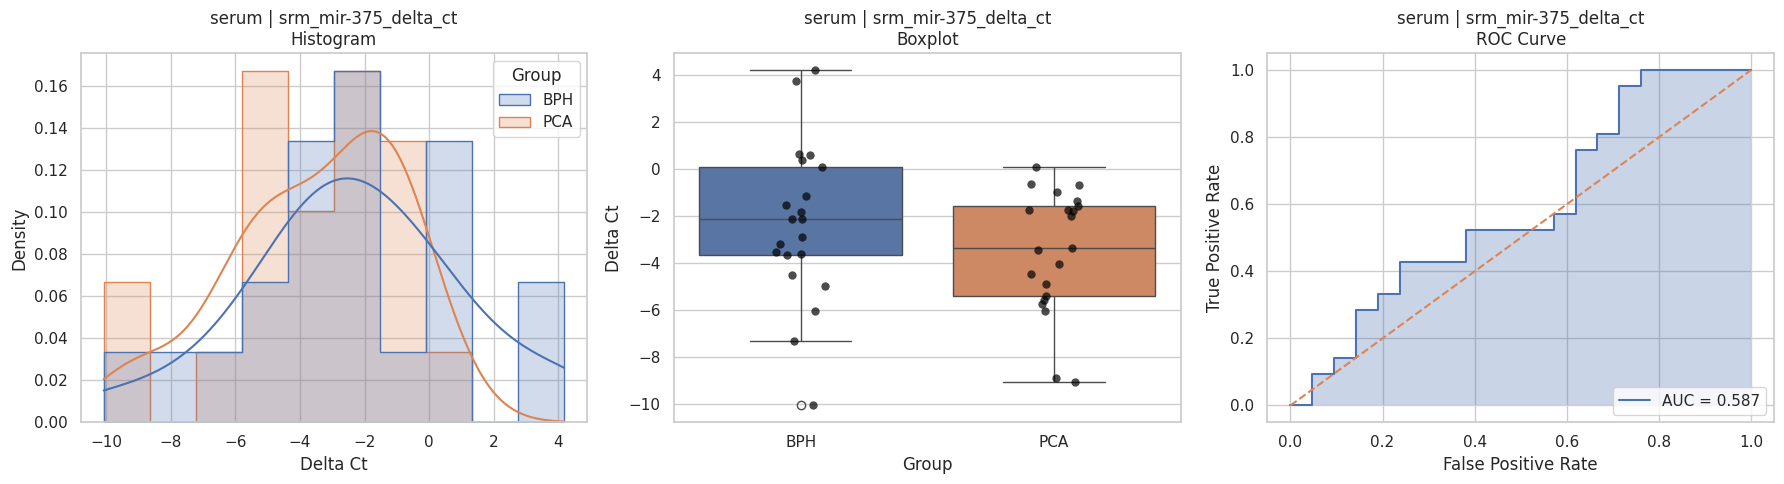


BIOFLUID: TISSUE

Group counts:
labels
1    19
0    13
Name: count, dtype: int64

Delta Ct biomarkers:
['tis_21-5p_delta_ct', 'tis_19b-3p_delta_ct', 'tis_mir-375_delta_ct']

Biomarker: tis_21-5p_delta_ct
BPH stats:
  mean: 1.1749
  median: 1.7698
  std: 4.7249
  iqr: 2.9132
PCA stats:
  mean: -0.6842
  median: -0.8823
  std: 3.7191
  iqr: 4.6045
Normality p-values -> BPH: 0.3385, PCA: 0.6852
Statistical test: Independent t-test
p-value: 0.2473
AUC (direction-corrected): 0.6316
Direction: PCA < BPH (ΔCt inverted)


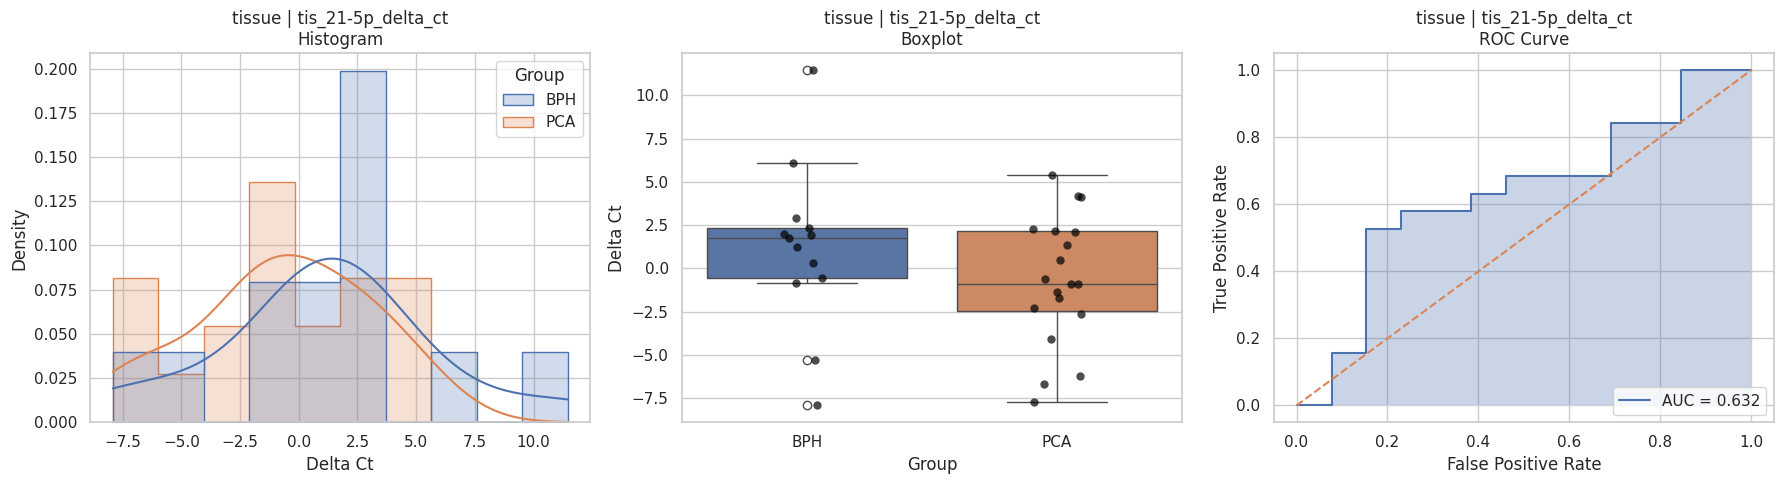


Biomarker: tis_19b-3p_delta_ct
BPH stats:
  mean: -1.0276
  median: -0.3190
  std: 3.1763
  iqr: 1.0097
PCA stats:
  mean: -3.7205
  median: -3.8552
  std: 4.0368
  iqr: 3.3115
Normality p-values -> BPH: 0.0185, PCA: 0.4456
Statistical test: Mann–Whitney U
p-value: 0.0551
AUC (direction-corrected): 0.7045
Direction: PCA < BPH (ΔCt inverted)


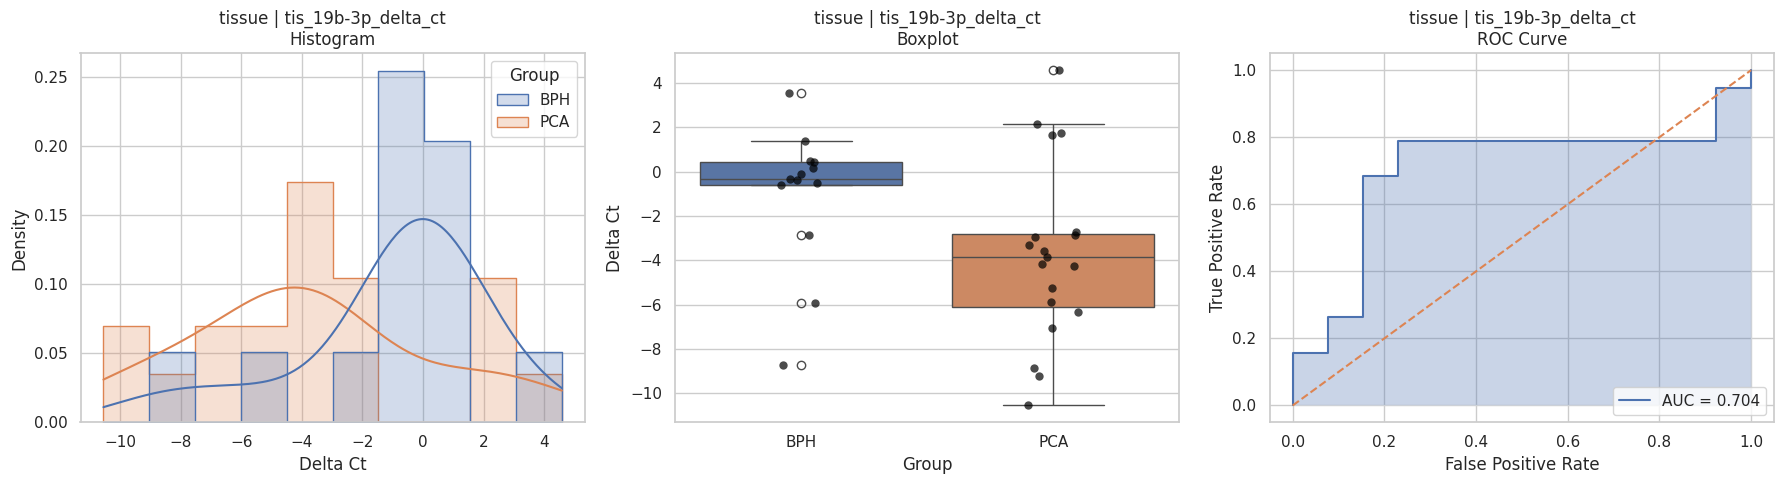


Biomarker: tis_mir-375_delta_ct
BPH stats:
  mean: -0.3742
  median: 0.3155
  std: 4.5956
  iqr: 5.2988
PCA stats:
  mean: -1.2084
  median: -1.0377
  std: 4.3082
  iqr: 4.4793
Normality p-values -> BPH: 0.8485, PCA: 0.7853
Statistical test: Independent t-test
p-value: 0.6096
AUC (direction-corrected): 0.5749
Direction: PCA < BPH (ΔCt inverted)


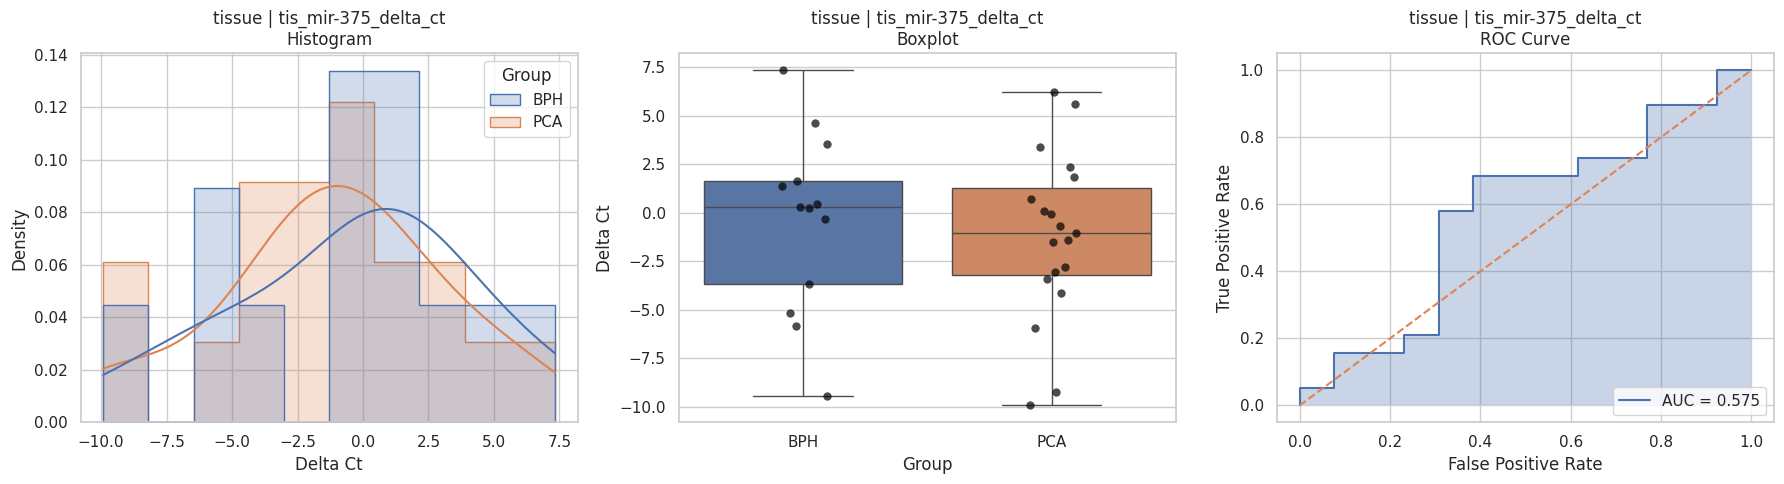

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro, ttest_ind, mannwhitneyu
from sklearn.metrics import roc_curve, roc_auc_score

# -----------------------------
# Configuration
# -----------------------------
file_path = "preprocessed_data.xlsx"
biofluids = ["urine", "blood", "serum", "tissue"]

sns.set(style="whitegrid")

# -----------------------------
# Main analysis
# -----------------------------
for biofluid in biofluids:

    print("\n===================================")
    print(f"BIOFLUID: {biofluid.upper()}")
    print("===================================")

    # 1. Read data
    df = pd.read_excel(file_path, sheet_name=biofluid)

    print("\nGroup counts:")
    print(df["labels"].value_counts())

    # 2. Select ΔCt columns
    delta_ct_cols = [col for col in df.columns if "delta_ct" in col]
    print("\nDelta Ct biomarkers:")
    print(delta_ct_cols)

    for biomarker in delta_ct_cols:

        df_plot = df[["labels", biomarker]].dropna().copy()
        df_plot["Group"] = df_plot["labels"].map({0: "BPH", 1: "PCA"})

        bph = df_plot[df_plot["labels"] == 0][biomarker]
        pca = df_plot[df_plot["labels"] == 1][biomarker]

        if len(bph) < 3 or len(pca) < 3:
            continue

        # -----------------------------
        # Descriptive statistics
        # -----------------------------
        def describe(x):
            return {
                "mean": np.mean(x),
                "median": np.median(x),
                "std": np.std(x, ddof=1),
                "iqr": np.percentile(x, 75) - np.percentile(x, 25)
            }

        desc_bph = describe(bph)
        desc_pca = describe(pca)

        # -----------------------------
        # Normality test
        # -----------------------------
        p_bph_norm = shapiro(bph).pvalue
        p_pca_norm = shapiro(pca).pvalue

        if p_bph_norm > 0.05 and p_pca_norm > 0.05:
            stat, p_val = ttest_ind(bph, pca, equal_var=False)
            test_name = "Independent t-test"
        else:
            stat, p_val = mannwhitneyu(bph, pca, alternative="two-sided")
            test_name = "Mann–Whitney U"

        # -----------------------------
        # ROC & AUC
        # -----------------------------
        y_true = df_plot["labels"].values
        y_score = df_plot[biomarker].values

        auc_raw = roc_auc_score(y_true, y_score)

        if auc_raw < 0.5:
            y_score = -y_score
            auc = 1 - auc_raw
            direction = "PCA < BPH (ΔCt inverted)"
        else:
            auc = auc_raw
            direction = "PCA > BPH"

        fpr, tpr, thresholds = roc_curve(y_true, y_score)
        # -----------------------------
        # Print results
        # -----------------------------
        print("\nBiomarker:", biomarker)
        print("BPH stats:")
        for k, v in desc_bph.items():
            print(f"  {k}: {v:.4f}")

        print("PCA stats:")
        for k, v in desc_pca.items():
            print(f"  {k}: {v:.4f}")

        print(f"Normality p-values -> BPH: {p_bph_norm:.4f}, PCA: {p_pca_norm:.4f}")
        print("Statistical test:", test_name)
        print(f"p-value: {p_val:.4f}")
        print(f"AUC (direction-corrected): {auc:.4f}")
        print(f"Direction: {direction}")


        # -----------------------------
        # Combined figure (3 subplots)
        # -----------------------------
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # 1️⃣ Histogram + KDE
        sns.histplot(
            data=df_plot,
            x=biomarker,
            hue="Group",
            kde=True,
            stat="density",
            bins=10,
            element="step",
            common_norm=False,
            ax=axes[0]
        )
        axes[0].set_title(f"{biofluid} | {biomarker}\nHistogram")
        axes[0].set_xlabel("Delta Ct")
        axes[0].set_ylabel("Density")

        # 2️⃣ Boxplot + Stripplot
        sns.boxplot(
            data=df_plot,
            x="Group",
            y=biomarker,
            hue="Group",
            dodge=False,
            ax=axes[1]
        )
        sns.stripplot(
            data=df_plot,
            x="Group",
            y=biomarker,
            color="black",
            size=6,
            jitter=True,
            alpha=0.7,
            ax=axes[1]
        )
        axes[1].set_title(f"{biofluid} | {biomarker}\nBoxplot")
        axes[1].set_ylabel("Delta Ct")
        # axes[1].legend_.remove()

        # 3️⃣ ROC curve
        axes[2].plot(fpr, tpr, label=f"AUC = {auc:.3f}")
        axes[2].fill_between(fpr, tpr, alpha=0.3)
        axes[2].plot([0, 1], [0, 1], linestyle="--")

        axes[2].set_xlabel("False Positive Rate")
        axes[2].set_ylabel("True Positive Rate")
        axes[2].set_title(f"{biofluid} | {biomarker}\nROC Curve")
        axes[2].legend(loc="lower right")

        plt.tight_layout()
        plt.show()



## B. Cross-biofluid comparison


BIOMARKER: 21-5p

--- Group: BPH ---
Kruskal–Wallis p-value: 5.8579e-06
Post-hoc Dunn test (Bonferroni corrected):
           urine     blood     serum    tissue
urine   1.000000  0.000001  0.007108  0.078505
blood   0.000001  1.000000  0.312615  0.205260
serum   0.007108  0.312615  1.000000  1.000000
tissue  0.078505  0.205260  1.000000  1.000000

--- Group: PCA ---
Kruskal–Wallis p-value: 8.1249e-08
Post-hoc Dunn test (Bonferroni corrected):
               urine         blood     serum    tissue
urine   1.000000e+00  1.993141e-07  0.001284  0.000029
blood   1.993141e-07  1.000000e+00  1.000000  1.000000
serum   1.283913e-03  1.000000e+00  1.000000  1.000000
tissue  2.928250e-05  1.000000e+00  1.000000  1.000000


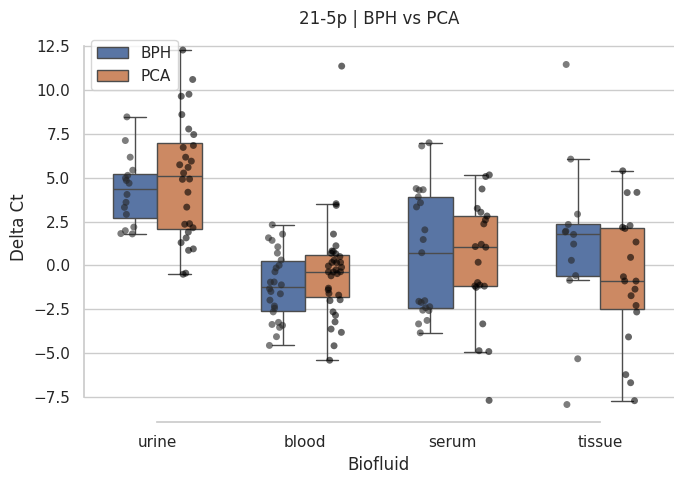


BIOMARKER: 19b-3p

--- Group: BPH ---
Kruskal–Wallis p-value: 4.2777e-10
Post-hoc Dunn test (Bonferroni corrected):
               urine     blood         serum    tissue
urine   1.000000e+00  0.000015  5.782258e-10  0.243205
blood   1.452818e-05  1.000000  1.606476e-01  0.185285
serum   5.782258e-10  0.160648  1.000000e+00  0.000533
tissue  2.432048e-01  0.185285  5.334166e-04  1.000000

--- Group: PCA ---
Kruskal–Wallis p-value: 1.4461e-13
Post-hoc Dunn test (Bonferroni corrected):
               urine     blood         serum    tissue
urine   1.000000e+00  0.000048  2.887915e-14  0.000089
blood   4.832609e-05  1.000000  2.583939e-04  1.000000
serum   2.887915e-14  0.000258  1.000000e+00  0.012648
tissue  8.901789e-05  1.000000  1.264848e-02  1.000000


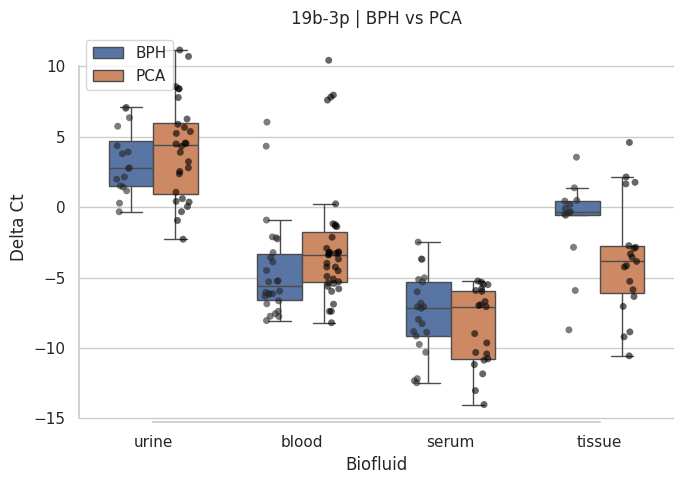


BIOMARKER: mir-375

--- Group: BPH ---
Kruskal–Wallis p-value: 3.0052e-11
Post-hoc Dunn test (Bonferroni corrected):
               urine         blood         serum    tissue
urine   1.000000e+00  1.000000e+00  4.758343e-08  0.000096
blood   1.000000e+00  1.000000e+00  9.078290e-08  0.000389
serum   4.758343e-08  9.078290e-08  1.000000e+00  1.000000
tissue  9.619321e-05  3.894963e-04  1.000000e+00  1.000000

--- Group: PCA ---
Kruskal–Wallis p-value: 4.9685e-15
Post-hoc Dunn test (Bonferroni corrected):
               urine         blood         serum        tissue
urine   1.000000e+00  1.000000e+00  7.021527e-09  9.099143e-06
blood   1.000000e+00  1.000000e+00  5.317820e-11  2.818055e-07
serum   7.021527e-09  5.317820e-11  1.000000e+00  1.000000e+00
tissue  9.099143e-06  2.818055e-07  1.000000e+00  1.000000e+00


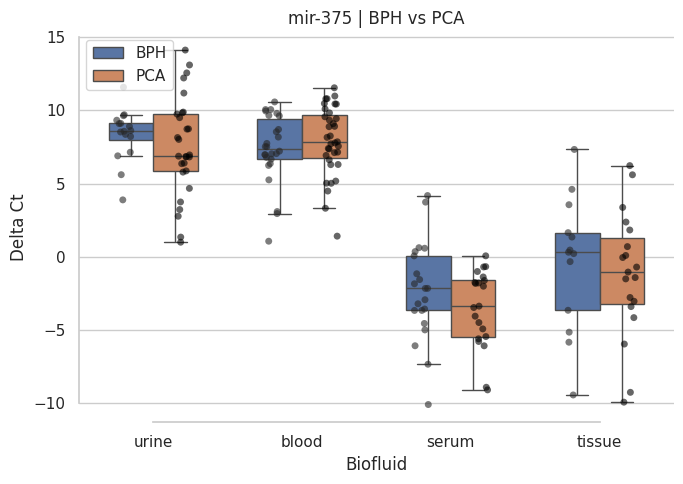

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal
import scikit_posthocs as sp


file_path = "preprocessed_data.xlsx"

biomarkers = ["21-5p", "19b-3p", "mir-375"]

prefix = {
    "urine": "urn",
    "blood": "bld",
    "serum": "srm",
    "tissue": "tis"
}

biofluids = list(prefix.keys())
labels_map = {0: "BPH", 1: "PCA"}

sns.set(style="whitegrid")

# -----------------------------
# Load all biofluids
# -----------------------------
dfs = {}
for bio in biofluids:
    df = pd.read_excel(file_path, sheet_name=bio)
    df["biofluid"] = bio
    dfs[bio] = df

# -----------------------------
# Cross-biofluid comparison
# -----------------------------
for biomarker in biomarkers:

    print("\n===================================")
    print(f"BIOMARKER: {biomarker}")
    print("===================================")

    for label, label_name in labels_map.items():

        print(f"\n--- Group: {label_name} ---")

        long_data = []

        # 1. Collect data from each biofluid (USED FOR STATS ONLY)
        for bio in biofluids:
            col_name = f"{prefix[bio]}_{biomarker}_delta_ct"
            if col_name not in dfs[bio].columns:
                continue

            temp = dfs[bio][dfs[bio]["labels"] == label][[col_name]].dropna().copy()
            temp["biofluid"] = bio
            temp.rename(columns={col_name: "delta_ct"}, inplace=True)
            long_data.append(temp)

        if len(long_data) < 2:
            print("Not enough biofluids to compare.")
            continue

        data = pd.concat(long_data, ignore_index=True)

        # 2. Keep biofluids with ≥3 samples
        valid_biofluids = [
            b for b in biofluids
            if len(data[data["biofluid"] == b]) >= 3
        ]

        if len(valid_biofluids) < 2:
            print("Not enough biofluids with sufficient samples.")
            continue

        data = data[data["biofluid"].isin(valid_biofluids)]

        # 3. Kruskal–Wallis test
        groups = [
            data[data["biofluid"] == b]["delta_ct"]
            for b in valid_biofluids
        ]

        h_stat, p_kw = kruskal(*groups)
        print(f"Kruskal–Wallis p-value: {p_kw:.4e}")

        # 4. Dunn post-hoc test
        if p_kw < 0.05:
            print("Post-hoc Dunn test (Bonferroni corrected):")

            dunn = sp.posthoc_dunn(
                data,
                val_col="delta_ct",
                group_col="biofluid",
                p_adjust="bonferroni"
            )

            dunn = dunn.loc[valid_biofluids, valid_biofluids]
            print(dunn)
        else:
            print("No significant cross-biofluid difference.")

    # =========================================================
    # 5. CORRECT PLOT — BPH vs PCA per biofluid (single figure)
    # =========================================================
    plot_data = []

    for lbl, lbl_name in labels_map.items():
        for bio in biofluids:
            col_name = f"{prefix[bio]}_{biomarker}_delta_ct"
            if col_name not in dfs[bio].columns:
                continue

            df_tmp = dfs[bio][dfs[bio]["labels"] == lbl][[col_name]].dropna().copy()
            if df_tmp.empty:
                continue

            df_tmp["biofluid"] = bio
            df_tmp["group"] = lbl_name
            df_tmp.rename(columns={col_name: "delta_ct"}, inplace=True)
            plot_data.append(df_tmp)

    plot_data = pd.concat(plot_data, ignore_index=True)

    fig, ax = plt.subplots(figsize=(7, 5))

    sns.boxplot(
        data=plot_data,
        x="biofluid",
        y="delta_ct",
        hue="group",
        width=0.6,
        fliersize=0,
        linewidth=1,
        ax=ax
    )

    sns.stripplot(
        data=plot_data,
        x="biofluid",
        y="delta_ct",
        hue="group",
        dodge=True,
        palette="dark:black",
        size=5,
        alpha=0.6,
        ax=ax
    )


    ax.set_xlabel("Biofluid")
    ax.set_ylabel("Delta Ct")
    ax.set_title(f"{biomarker} | BPH vs PCA")

    # Fix duplicated legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], title="", loc="upper left")

    sns.despine(trim=True)
    plt.tight_layout()
    # plt.savefig(f"B/{biomarker}-{label_name}_cross-biofluid.png", dpi=300)
    plt.show()


## C. Biofluid X Disease interaction


BIOMARKER: 21-5p
                               sum_sq     df          F        PR(>F)
C(biofluid)             161997.807650    3.0  29.868301  1.405663e-15
C(disease)                  42.424234    1.0   0.023466  8.784324e-01
C(biofluid):C(disease)    6517.388041    3.0   1.201642  3.108060e-01
Residual                309153.004232  171.0        NaN           NaN

BIOMARKER: 19b-3p
                               sum_sq     df          F        PR(>F)
C(biofluid)             278227.382445    3.0  86.597076  4.013369e-34
C(disease)                  32.329246    1.0   0.030187  8.622721e-01
C(biofluid):C(disease)   13420.170070    3.0   4.176970  6.956956e-03
Residual                183135.061307  171.0        NaN           NaN

BIOMARKER: mir-375
                               sum_sq     df           F        PR(>F)
C(biofluid)             327120.974860    3.0  126.264425  3.755627e-43
C(disease)                 506.753703    1.0    0.586801  4.447150e-01
C(biofluid):C(disease)    2897

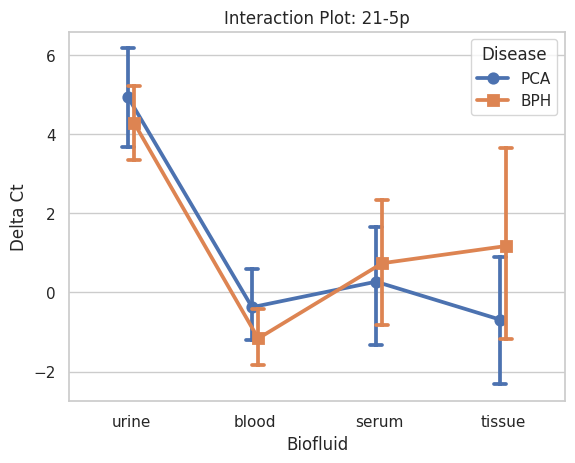

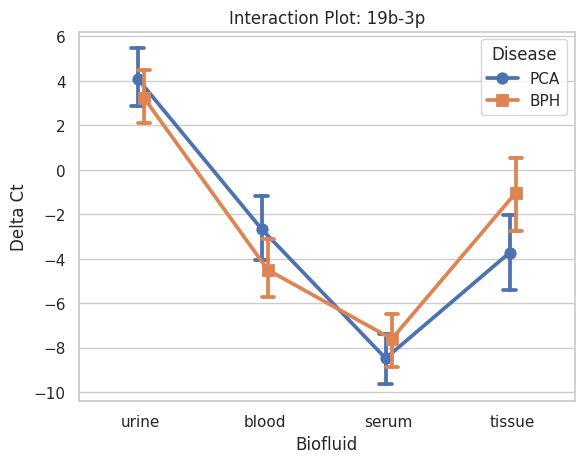

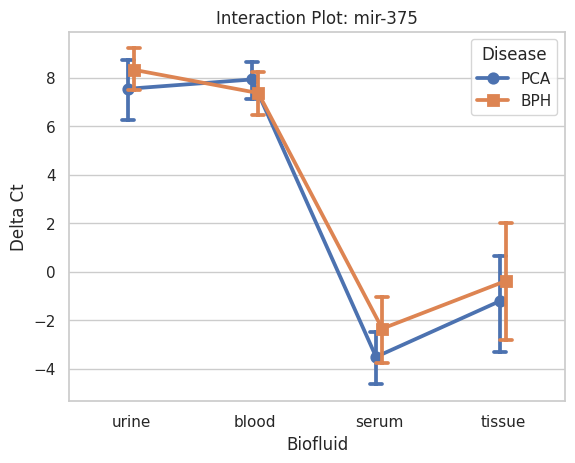

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from scipy.stats import rankdata
from statsmodels.stats.anova import anova_lm

# -----------------------------
# Configuration
# -----------------------------
file_path = "preprocessed_data.xlsx"

biomarkers = ["21-5p", "19b-3p", "mir-375"]

prefix = {
    "urine": "urn",
    "blood": "bld",
    "serum": "srm",
    "tissue": "tis"
}

biofluids = list(prefix.keys())

# -----------------------------
# Load and reshape data
# -----------------------------
long_data = []

for bio in biofluids:
    df = pd.read_excel(file_path, sheet_name=bio)

    for bm in biomarkers:
        col = f"{prefix[bio]}_{bm}_delta_ct"
        if col not in df.columns:
            continue

        temp = df[["labels", col]].dropna()
        temp["biofluid"] = bio
        temp["biomarker"] = bm
        temp.rename(columns={col: "delta_ct"}, inplace=True)

        long_data.append(temp)

data = pd.concat(long_data, ignore_index=True)

# Encode disease as categorical
data["disease"] = data["labels"].map({0: "BPH", 1: "PCA"})

# -----------------------------
# Interaction analysis
# -----------------------------
for bm in biomarkers:

    print("\n===================================")
    print(f"BIOMARKER: {bm}")
    print("===================================")

    df_bm = data[data["biomarker"] == bm].copy()

    # Rank transform (non-parametric)
    df_bm["rank_delta_ct"] = rankdata(df_bm["delta_ct"])

    # Linear model with interaction
    model = smf.ols(
        "rank_delta_ct ~ C(biofluid) * C(disease)",
        data=df_bm
    ).fit()

    # ANOVA table (Type II)
    anova_table = anova_lm(model, typ=2)

    print(anova_table)

# -----------------------------
# Interaction plots
# -----------------------------
for bm in biomarkers:

    plt.figure()
    sns.pointplot(
        data=data[data["biomarker"] == bm],
        x="biofluid",
        y="delta_ct",
        hue="disease",
        dodge=True,
        markers=["o", "s"],
        capsize=0.1
    )
    plt.title(f"Interaction Plot: {bm}")
    plt.xlabel("Biofluid")
    plt.ylabel("Delta Ct")
    plt.legend(title="Disease")
    plt.savefig(f"C/{bm}-interaction plot.png")
    plt.show()


BIOMARKER: 21-5p

Effect,F-statistic,p-value,Significance,Explanation
C(biofluid),29.868,0.0000,Significant effect,ΔCt values differ across biofluids (urine-blood-serum-tissue)
C(disease),0.023,0.8784,Not significant,Overall ΔCt difference between BPH and PCA
C(biofluid):C(disease),1.202,0.3108,Not significant,Disease-related ΔCt differences depend on biofluid
Residual,nan,nan,Not significant,Residual variance

Aligned Rank Transform (ART) two-way ANOVA (with Interaction)
                Effect  F-statistic p-value       Significance                                                   Explanation
           C(biofluid)       29.868  0.0000 Significant effect ΔCt values differ across biofluids (urine-blood-serum-tissue)
            C(disease)        0.023  0.8784    Not significant                    Overall ΔCt difference between BPH and PCA
C(biofluid):C(disease)        1.202  0.3108    Not significant            Disease-related ΔCt differences depend on biofluid
              Residual

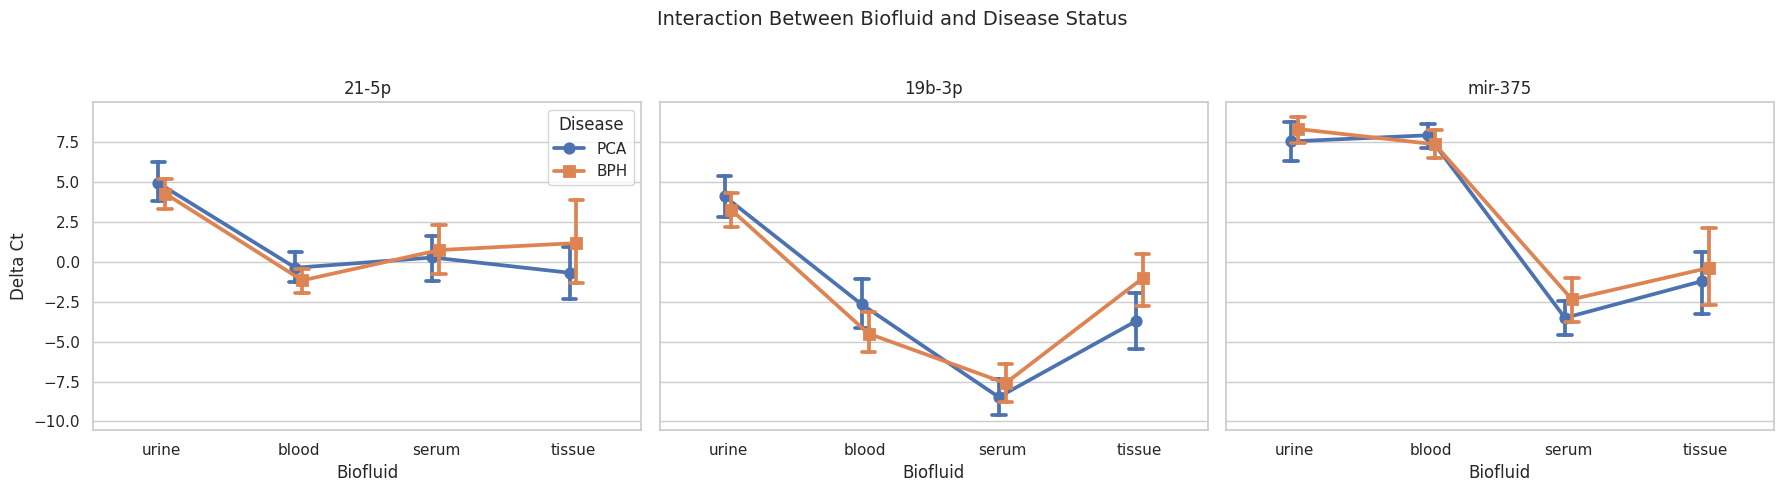

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
from scipy.stats import rankdata
from statsmodels.stats.anova import anova_lm

# -----------------------------
# Configuration
# -----------------------------
file_path = "preprocessed_data.xlsx"

biomarkers = ["21-5p", "19b-3p", "mir-375"]

prefix = {
    "urine": "urn",
    "blood": "bld",
    "serum": "srm",
    "tissue": "tis"
}

biofluids = list(prefix.keys())

sns.set(style="whitegrid")

# -----------------------------
# Load and reshape data
# -----------------------------
long_data = []

for bio in biofluids:
    df = pd.read_excel(file_path, sheet_name=bio)

    for bm in biomarkers:
        col = f"{prefix[bio]}_{bm}_delta_ct"
        if col not in df.columns:
            continue

        temp = df[["labels", col]].dropna().copy()
        temp["biofluid"] = bio
        temp["biomarker"] = bm
        temp.rename(columns={col: "delta_ct"}, inplace=True)

        long_data.append(temp)

data = pd.concat(long_data, ignore_index=True)

# Encode disease
data["disease"] = data["labels"].map({0: "BPH", 1: "PCA"})

# =========================================================
# INTERACTION ANALYSIS (Rank-based ANOVA)
# =========================================================
for bm in biomarkers:

    print("\n" + "=" * 60)
    print(f"BIOMARKER: {bm}")
    print("=" * 60)

    df_bm = data[data["biomarker"] == bm].copy()

    # Rank transform (non-parametric factorial ANOVA)
    df_bm["rank_delta_ct"] = rankdata(df_bm["delta_ct"])

    # Linear model with interaction
    model = smf.ols(
        "rank_delta_ct ~ C(biofluid) * C(disease)",
        data=df_bm
    ).fit()

    anova_table = anova_lm(model, typ=2)

    # -----------------------------
    # Explainable ANOVA table
    # -----------------------------
    summary_rows = []

    for effect in anova_table.index:
        f_val = anova_table.loc[effect, "F"]
        p_val = anova_table.loc[effect, "PR(>F)"]

        if effect == "C(biofluid)":
            meaning = "ΔCt values differ across biofluids (urine-blood-serum-tissue)"
        elif effect == "C(disease)":
            meaning = "Overall ΔCt difference between BPH and PCA"
        elif effect == "C(biofluid):C(disease)":
            meaning = "Disease-related ΔCt differences depend on biofluid"
        else:
            meaning = "Residual variance"

        interpretation = (
            "Significant effect" if p_val < 0.05 else "Not significant"
        )

        summary_rows.append({
            "Effect": effect,
            "F-statistic": round(f_val, 3),
            "p-value": f"{p_val:.4f}",
            "Significance": interpretation,
            "Explanation": meaning
        })

    summary_table = pd.DataFrame(summary_rows)

    print("\nEffect,F-statistic,p-value,Significance,Explanation")
    for _, row in summary_table.iterrows():
        print(
            f"{row['Effect']},"
            f"{row['F-statistic']},"
            f"{row['p-value']},"
            f"{row['Significance']},"
            f"{row['Explanation']}"
        )

    print("\nAligned Rank Transform (ART) two-way ANOVA (with Interaction)")
    print(summary_table.to_string(index=False))


# =========================================================
# INTERACTION PLOTS (SUBPLOTS)
# =========================================================
fig, axes = plt.subplots(1, len(biomarkers), figsize=(6 * len(biomarkers), 5), sharey=True)

if len(biomarkers) == 1:
    axes = [axes]

for ax, bm in zip(axes, biomarkers):

    sns.pointplot(
        data=data[data["biomarker"] == bm],
        x="biofluid",
        y="delta_ct",
        hue="disease",
        dodge=True,
        markers=["o", "s"],
        capsize=0.1,
        ax=ax
    )

    ax.set_title(f"{bm}")
    ax.set_xlabel("Biofluid")
    ax.set_ylabel("Delta Ct")

    # Remove duplicate legends
    if ax != axes[0]:
        ax.get_legend().remove()

axes[0].legend(title="Disease", loc="best")

plt.suptitle("Interaction Between Biofluid and Disease Status", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.savefig("C/interaction_plots_all_biomarkers.png", dpi=300)
plt.show()


## D. Effect size

### a. within

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import shapiro

# -----------------------------
# Configuration
# -----------------------------
file_path = "preprocessed_data.xlsx"

biofluids = ["urine", "blood", "serum", "tissue"]
biomarkers = ["21-5p", "19b-3p", "mir-375"]

prefix = {
    "urine": "urn",
    "blood": "bld",
    "serum": "srm",
    "tissue": "tis"
}

# -----------------------------
# Effect size functions
# -----------------------------
def cohens_d(x, y):
    x, y = np.array(x), np.array(y)
    nx, ny = len(x), len(y)
    pooled_std = np.sqrt(
        ((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / (nx + ny - 2)
    )
    return (np.mean(x) - np.mean(y)) / pooled_std


def cliffs_delta(x, y):
    x, y = np.array(x), np.array(y)
    nx, ny = len(x), len(y)
    greater = sum(i > j for i in x for j in y)
    less = sum(i < j for i in x for j in y)
    return (greater - less) / (nx * ny)


def interpret_cohens_d(d):
    d = abs(d)
    if d < 0.2:
        return "negligible"
    elif d < 0.5:
        return "small"
    elif d < 0.8:
        return "medium"
    else:
        return "large"


def interpret_cliffs_delta(delta):
    delta = abs(delta)
    if delta < 0.147:
        return "negligible"
    elif delta < 0.33:
        return "small"
    elif delta < 0.474:
        return "medium"
    else:
        return "large"

# -----------------------------
# Compute effect sizes + labels
# -----------------------------
results = []

for bio in biofluids:
    df = pd.read_excel(file_path, sheet_name=bio)

    for bm in biomarkers:
        col = f"{prefix[bio]}_{bm}_delta_ct"
        if col not in df.columns:
            continue

        bph = df[df["labels"] == 0][col].dropna()
        pca = df[df["labels"] == 1][col].dropna()

        if len(bph) < 3 or len(pca) < 3:
            continue

        # Normality check
        p_bph = shapiro(bph).pvalue
        p_pca = shapiro(pca).pvalue
        normal = (p_bph > 0.05) and (p_pca > 0.05)

        d = cohens_d(bph, pca)
        delta = cliffs_delta(bph, pca)

        if normal:
            chosen_effect = "Cohen's d"
            magnitude = interpret_cohens_d(d)
        else:
            chosen_effect = "Cliff's Delta"
            magnitude = interpret_cliffs_delta(delta)

        results.append({
            "biofluid": bio,
            "biomarker": bm,
            "BPH_n": len(bph),
            "PCA_n": len(pca),
            "cohens_d": d,
            "cliffs_delta": delta,
            "preferred_effect": chosen_effect,
            "magnitude": magnitude
        })

# -----------------------------
# Results table
# -----------------------------
effect_size_df = pd.DataFrame(results)
# print(effect_size_df)
effect_size_df

,biofluid,biomarker,BPH_n,PCA_n,cohens_d,cliffs_delta,preferred_effect,magnitude
0,urine,21-5p,16,28,-0.219641,-0.111607,Cohen's d,small
1,urine,19b-3p,16,28,-0.271930,-0.147321,Cohen's d,small
2,urine,mir-375,16,28,0.266068,0.183036,Cohen's d,small
3,blood,21-5p,26,35,-0.314980,-0.151648,Cliff's Delta,small
4,blood,19b-3p,26,35,-0.449055,-0.331868,Cliff's Delta,medium
5,blood,mir-375,26,35,-0.239406,-0.153846,Cliff's Delta,small
6,serum,21-5p,21,21,0.132628,0.020408,Cliff's Delta,negligible
7,serum,19b-3p,21,21,0.308164,0.151927,Cliff's Delta,small
8,serum,mir-375,21,21,0.384631,0.174603,Cohen's d,small
9,tissue,21-5p,13,19,0.447892,0.263158,Cohen's d,small


### b. cross-biofluid

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import kruskal

# -----------------------------
# Configuration
# -----------------------------
file_path = "preprocessed_data.xlsx"

biomarkers = ["21-5p", "19b-3p", "mir-375"]

prefix = {
    "urine": "urn",
    "blood": "bld",
    "serum": "srm",
    "tissue": "tis"
}

biofluids = list(prefix.keys())
label_map = {0: "BPH", 1: "PCA"}

# -----------------------------
# Epsilon-squared effect size
# -----------------------------
def epsilon_squared(H, n, k):
    # H = Kruskal–Wallis statistic
    # n = total sample size
    # k = number of groups
    return (H - k + 1) / (n - k)

def interpret_epsilon_squared(eps):
    if eps < 0.01:
        return "negligible"
    elif eps < 0.06:
        return "small"
    elif eps < 0.14:
        return "medium"
    else:
        return "large"

# -----------------------------
# Load biofluid data
# -----------------------------
dfs = {}
for bio in biofluids:
    dfs[bio] = pd.read_excel(file_path, sheet_name=bio)

# -----------------------------
# Cross-biofluid effect size
# -----------------------------
results = []

for bm in biomarkers:

    for label, label_name in label_map.items():

        values = []
        group_names = []

        for bio in biofluids:
            col = f"{prefix[bio]}_{bm}_delta_ct"
            if col not in dfs[bio].columns:
                continue

            v = dfs[bio][dfs[bio]["labels"] == label][col].dropna()
            if len(v) >= 3:
                values.append(v)
                group_names.append(bio)

        if len(values) < 2:
            continue

        # Kruskal–Wallis
        H, p_kw = kruskal(*values)

        n_total = sum(len(v) for v in values)
        k = len(values)

        eps = epsilon_squared(H, n_total, k)
        magnitude = interpret_epsilon_squared(eps)

        results.append({
            "biomarker": bm,
            "group": label_name,
            "biofluids_compared": group_names,
            "H_statistic": H,
            "p_value": p_kw,
            "epsilon_squared": eps,
            "magnitude": magnitude
        })

# -----------------------------
# Results table
# -----------------------------
effect_size_cross_df = pd.DataFrame(results)
# print(effect_size_cross_df)
effect_size_cross_df

,biomarker,group,biofluids_compared,H_statistic,p_value,epsilon_squared,magnitude
0,21-5p,BPH,"[urine, blood, serum, tissue]",27.010407,5.857854e-06,0.333478,large
1,21-5p,PCA,"[urine, blood, serum, tissue]",35.832421,8.124864e-08,0.331641,large
2,19b-3p,BPH,"[urine, blood, serum, tissue]",46.576018,4.277682e-10,0.605222,large
3,19b-3p,PCA,"[urine, blood, serum, tissue]",62.849729,1.446101e-13,0.604543,large
4,mir-375,BPH,"[urine, blood, serum, tissue]",51.993158,3.005154e-11,0.680461,large
5,mir-375,PCA,"[urine, blood, serum, tissue]",69.691942,4.968454e-15,0.673656,large


##

# Stat